# Tests Complets pour l'Implémentation FCI

Ce notebook contient tous les tests nécessaires pour évaluer l'algorithme FCI selon les critères du projet MADI:
- Tests sur données simulées
- Comparaison avec MIIC (pyAgrum)
- Analyse de structure et complexité computationnelle

## 1. Installation et Imports

In [ ]:
!pip install pyagrum numpy pandas graphviz matplotlib

In [1]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
import pgmpy
import graphviz
import numpy as np
import matplotlib.pyplot as plt
# from causallearn.search.ConstraintBased.FCI import fci
# from causallearn.utils.cit import fisherz, gsq
# from causallearn.utils.GraphUtils import GraphUtils
# from IPython.display import Image, display

mr = gum.MeekRules()

In [2]:
%load_ext autoreload
%autoreload 2

from FCI import *
import utils

## 2. Test 1 - Réseau Bayésien Simple 

Test 1: Réseau simple (4 variables)
------------------------------------------------------------
Réseau créé: 5 variables, 6 arcs


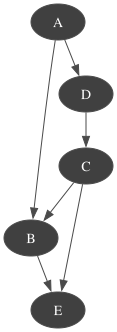

In [3]:
# Création d'un réseau bayésien simple avec une structure connue
print("Test 1: Réseau simple (4 variables)")
print("-" * 60)

bn_simple = gum.BayesNet("Simple_Network")

a = bn_simple.add(gum.LabelizedVariable('A', 'Variable A', 2))
b = bn_simple.add(gum.LabelizedVariable('B', 'Variable B', 2))
c = bn_simple.add(gum.LabelizedVariable('C', 'Variable C', 2))
d = bn_simple.add(gum.LabelizedVariable('D', 'Variable D', 2))
e = bn_simple.add(gum.LabelizedVariable('E', 'Variable E', 2))


bn_simple.addArc(a, b)
bn_simple.addArc(a, d)
bn_simple.addArc(b, e)
bn_simple.addArc(c, b)
bn_simple.addArc(c, e)
bn_simple.addArc(d, c)


bn_simple.generateCPTs()

print(f"Réseau créé: {bn_simple.size()} variables, {bn_simple.sizeArcs()} arcs")

# Visualisation
gnb.showBN(bn_simple)

In [24]:
# Génération des données
df_simple,_ = utils.generate_test_data(bn_simple, n_samples=5000)
print(f"Données générées: {len(df_simple)} échantillons")
print(f"\nAperçu des données:")
latent_var = (3,df_simple.columns[3])
df_simple = df_simple.drop(columns=latent_var[1])
print(latent_var)
df_simple.head()

Données générées: 5000 échantillons

Aperçu des données:
(3, 'D')


,A,B,C,E
0,0,1,1,1
1,0,0,0,1
2,0,0,0,0
3,1,1,0,0
4,1,1,0,1


Exécution de FCI...
FCI terminé en 0.050s

PAG résultant (FCI):


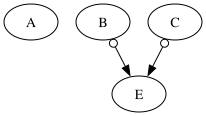

In [25]:
# Test FCI
print("Exécution de FCI...")
fci_simple, fci_time_simple = utils.measure_execution_time(run_FCI, df_simple, alpha=0.05, useGum=True)
print(f"FCI terminé en {fci_time_simple:.3f}s")

# Visualisation du résultat FCI
print("\nPAG résultant (FCI):")
# print(fci_simple.get_variables())
fci_simple.toDot()

Exécution de FCI (Gum=False)...
FCI terminé en 0.037s

PAG résultant (FCI):


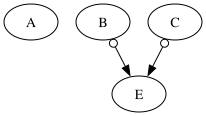

In [26]:
# Test FCI
print("Exécution de FCI (Gum=False)...")
fci_simple, fci_time_simple = utils.measure_execution_time(run_FCI, df_simple, alpha=0.05, useGum=False)
print(f"FCI terminé en {fci_time_simple:.3f}s")

# Visualisation du résultat FCI
print("\nPAG résultant (FCI):")
# print(fci_simple.get_variables())
fci_simple.toDot()

## 3. Comparaison avec MIIC

Exécution de MIIC...
MIIC terminé en 0.005s

PDAG résultant (MIIC):


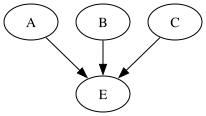

In [27]:
# Test MIIC
print("Exécution de MIIC...")
learner_simple = gum.BNLearner(df_simple)

def run_miic(learner):
    learner.useMIIC()
    return learner.learnPDAG()

miic_simple, miic_time_simple = utils.measure_execution_time(run_miic, learner_simple)
print(f"MIIC terminé en {miic_time_simple:.3f}s")

# Visualisation du résultat MIIC
print("\nPDAG résultant (MIIC):")
utils.labelize_pdag_nodes(miic_simple, bn_simple, latent_var)

In [28]:
comparison = utils.compare_structures(fci_simple, miic_simple, bn_simple, fci_time_simple, miic_time_simple, latent_variable=latent_var)

------------------------------------------------------------
COMPARAISON FCI vs MIIC
------------------------------------------------------------
Structure:
  FCI  - Total arêtes du squelette: 2
       - Orientées: 2
       - Taux de certitude: 50% (2/4)
  MIIC - Total arêtes du squelette : 3
       - Arcs: 3

Similarité:
  Arêtes communes: 2
  Jaccard similarity: 0.667

Temps d'exécution:
  FCI:  0.037s
  MIIC: 0.005s
  Ratio (FCI/MIIC): 7.31x


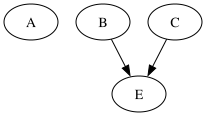

In [9]:
graph = fci_simple.return_PDAG(opt=1)
utils.labelize_pdag_nodes(graph, fci_simple)

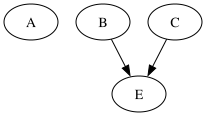

In [10]:
graph = fci_simple.return_PDAG(opt=2)
utils.labelize_pdag_nodes(graph, fci_simple)

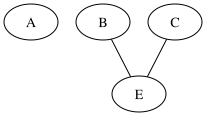

In [11]:
graph = fci_simple.return_PDAG(opt=3)
utils.labelize_pdag_nodes(graph, fci_simple)

## 4. Analyse selon les paramètres
Paramètres analysés :
- taille de l'échantillon 
- taille du réseau bayésien

In [ ]:
print("Analyse")
print("-" * 60)

n_vars_list = [4, 6, 8, 10, 12, 14]
n_samples = [100, 1000, 10000]
total_fci_times = {}
total_rfci_times = {}
total_miic_times = {}
total_n_edges_fci = {}
total_n_edges_miic = {}
total_jaccard_similarities = {}
total_certainty_score = {}
total_ratios = {}

for s in n_samples:
    print(f"\nTest avec écahntillon de taill {s} ...")
    fci_times = []
    rfci_times = []
    miic_times = []
    n_edges_fci = []
    n_edges_miic = []
    jaccard_similarities = []
    certainty_score = []
    ratios = []
    for n in n_vars_list:
        print(f"\nTest avec {n} variables...")
        
        # Création du réseau
        bn_test = gum.randomBN(n=n, names=[f'X{i}' for i in range(n)])
        bn_test.generateCPTs()
        
        # Génération des données
        df_test,_ = utils.generate_test_data(bn_test, n_samples=s)
        index = np.random.randint(0, len(df_test.columns))
        latent_var = (index, df_test.columns[index])
        df_test = df_test.drop(columns=latent_var[1])
        print(f"{latent_var=}")
        
        # FCI
        fci_result, t_fci = utils.measure_execution_time(run_FCI, df_test, alpha=0.05, useGum=True)
        fci_times.append(t_fci)
        
        # RFCI
        # rfci_result, t_rfci = utils.measure_execution_time(run_RFCI, df_test, alpha=0.05, useGum=True, bayesnet=bn_test)
        # rfci_times.append(t_rfci)
        
        # MIIC
        learner_test = gum.BNLearner(df_test)
        miic_result, t_miic = utils.measure_execution_time(run_miic, learner_test)
        miic_times.append(t_miic)

        comparison = utils.compare_structures(fci_result, miic_result, bn_test, t_fci, t_miic, latent_variable=latent_var, verbose=False)
        n_edges_fci.append(comparison['fci_total'])
        n_edges_miic.append(comparison['miic_total'])
        jaccard_similarities.append(comparison['jaccard_similarity'])
        certainty_score.append(comparison['fci_certainty_score'])
        ratios.append(comparison['t_ratio'])

    total_fci_times[s] = fci_times
    total_miic_times[s] = miic_times
    total_n_edges_fci[s] = n_edges_fci
    total_n_edges_miic[s] = n_edges_miic
    total_jaccard_similarities[s] = jaccard_similarities
    total_certainty_score[s] = certainty_score
    total_ratios[s] = ratios

Test : Analyse de scalabilité
------------------------------------------------------------

Test avec écahntillon de taill 100 ...

Test avec 4 variables...
latent_var=(0, 'X1')

Test avec 6 variables...
latent_var=(5, 'X1')

Test avec 8 variables...
latent_var=(0, 'X2')

Test avec 10 variables...
latent_var=(7, 'X9')

Test avec 12 variables...
latent_var=(4, 'X8')

Test avec 14 variables...
latent_var=(6, 'X6')

Test avec écahntillon de taill 1000 ...

Test avec 4 variables...
latent_var=(1, 'X2')

Test avec 6 variables...
latent_var=(1, 'X1')

Test avec 8 variables...
latent_var=(2, 'X3')

Test avec 10 variables...
latent_var=(4, 'X4')

Test avec 12 variables...
latent_var=(3, 'X1')

Test avec 14 variables...
latent_var=(0, 'X9')

Test avec écahntillon de taill 10000 ...

Test avec 4 variables...
latent_var=(3, 'X3')

Test avec 6 variables...
latent_var=(0, 'X2')

Test avec 8 variables...
latent_var=(5, 'X0')

Test avec 10 variables...
latent_var=(3, 'X8')

Test avec 12 variables...


In [30]:
plt.style.use('default')  # Style par défaut avec fond blanc
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

### Performance temporelle

In [59]:
total_fci_times

{100: [0.004925966262817383,
  0.0022656917572021484,
  0.002930164337158203,
  0.004634857177734375,
  0.00826716423034668,
  0.017902135848999023],
 1000: [0.0030488967895507812,
  0.004123210906982422,
  0.007524251937866211,
  0.010358095169067383,
  0.020892858505249023,
  0.031049013137817383],
 10000: [0.01027989387512207,
  0.036885976791381836,
  0.05060410499572754,
  0.16131114959716797,
  0.1802659034729004,
  0.5458130836486816]}

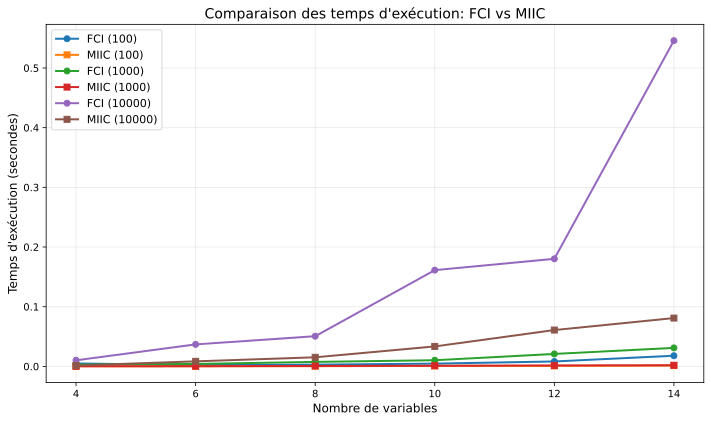


Résumé des temps d'exécution:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | FCI: 0.0049s | MIIC: 0.0003s | Ratio: 16.53x
n= 6 variables | FCI: 0.0023s | MIIC: 0.0003s | Ratio: 8.65x
n= 8 variables | FCI: 0.0029s | MIIC: 0.0004s | Ratio: 8.25x
n=10 variables | FCI: 0.0046s | MIIC: 0.0008s | Ratio: 5.52x
n=12 variables | FCI: 0.0083s | MIIC: 0.0008s | Ratio: 9.89x
n=14 variables | FCI: 0.0179s | MIIC: 0.0014s | Ratio: 13.24x

Taille de l'échantillo s = 1000
n= 4 variables | FCI: 0.0030s | MIIC: 0.0002s | Ratio: 17.14x
n= 6 variables | FCI: 0.0041s | MIIC: 0.0003s | Ratio: 12.97x
n= 8 variables | FCI: 0.0075s | MIIC: 0.0007s | Ratio: 10.81x
n=10 variables | FCI: 0.0104s | MIIC: 0.0011s | Ratio: 9.66x
n=12 variables | FCI: 0.0209s | MIIC: 0.0016s | Ratio: 12.77x
n=14 variables | FCI: 0.0310s | MIIC: 0.0019s | Ratio: 16.21x

Taille de l'échantillo s = 10000
n= 4 variables | FCI: 0.0103s | MIIC: 0.0015s | Ratio: 6.76x
n= 6 vari

In [60]:
# Comparaison des temps d'exécution
plt.figure(figsize=(10, 6))
for s in n_samples:
    plt.plot(n_vars_list, total_fci_times[s], marker='o', label=f'FCI ({s})', linewidth=2)
    plt.plot(n_vars_list, total_miic_times[s], marker='s', label=f'MIIC ({s})', linewidth=2)

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Temps d\'exécution (secondes)', fontsize=12)
plt.title('Comparaison des temps d\'exécution: FCI vs MIIC', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)

plt.tight_layout()
plt.show()

# Affichage des statistiques
print("\nRésumé des temps d'exécution:")
print("-" * 60)

for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        print(f"n={n:2d} variables | FCI: {total_fci_times[s][i]:.4f}s | MIIC: {total_miic_times[s][i]:.4f}s | Ratio: {total_ratios[s][i]:.2f}x")

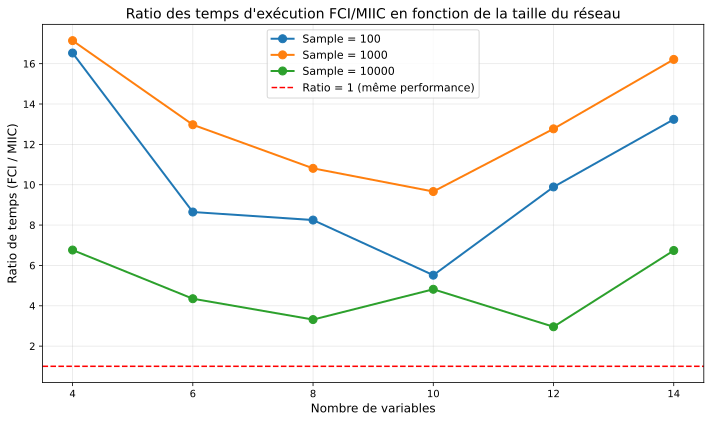


Résumé des ratios FCI/MIIC:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | Ratio:  16.53x
n= 6 variables | Ratio:   8.65x
n= 8 variables | Ratio:   8.25x
n=10 variables | Ratio:   5.52x
n=12 variables | Ratio:   9.89x
n=14 variables | Ratio:  13.24x

Taille de l'échantillo s = 1000
n= 4 variables | Ratio:  17.14x
n= 6 variables | Ratio:  12.97x
n= 8 variables | Ratio:  10.81x
n=10 variables | Ratio:   9.66x
n=12 variables | Ratio:  12.77x
n=14 variables | Ratio:  16.21x

Taille de l'échantillo s = 10000
n= 4 variables | Ratio:   6.76x
n= 6 variables | Ratio:   4.35x
n= 8 variables | Ratio:   3.32x
n=10 variables | Ratio:   4.82x
n=12 variables | Ratio:   2.96x
n=14 variables | Ratio:   6.74x


In [64]:
# Ratio FCI/MIIC
plt.figure(figsize=(10, 6))

for s in n_samples:
    plt.plot(n_vars_list, total_ratios[s], marker='o', linewidth=2, markersize=8, label=f'Sample = {s}')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Ratio = 1 (même performance)')

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Ratio de temps (FCI / MIIC)', fontsize=12)
plt.title('Ratio des temps d\'exécution FCI/MIIC en fonction de la taille du réseau', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)

plt.tight_layout()
plt.show()

# Affichage des statistiques détaillées
print("\nRésumé des ratios FCI/MIIC:")
print("-" * 60)
for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        print(f"n={n:2d} variables | Ratio: {total_ratios[s][i]:6.2f}x")

### Analyse de structure

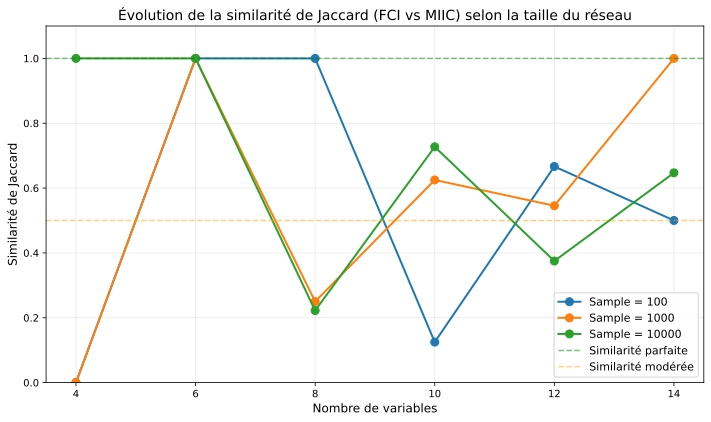


Résumé de la similarité de Jaccard:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | FCI:  1 arêtes | MIIC:  0 arêtes | Jaccard: 0.000
n= 6 variables | FCI:  1 arêtes | MIIC:  1 arêtes | Jaccard: 1.000
n= 8 variables | FCI:  2 arêtes | MIIC:  2 arêtes | Jaccard: 1.000
n=10 variables | FCI:  3 arêtes | MIIC:  6 arêtes | Jaccard: 0.125
n=12 variables | FCI:  4 arêtes | MIIC:  6 arêtes | Jaccard: 0.667
n=14 variables | FCI:  6 arêtes | MIIC:  9 arêtes | Jaccard: 0.500

Taille de l'échantillo s = 1000
n= 4 variables | FCI:  0 arêtes | MIIC:  0 arêtes | Jaccard: 0.000
n= 6 variables | FCI:  3 arêtes | MIIC:  3 arêtes | Jaccard: 1.000
n= 8 variables | FCI:  5 arêtes | MIIC:  5 arêtes | Jaccard: 0.250
n=10 variables | FCI:  7 arêtes | MIIC:  6 arêtes | Jaccard: 0.625
n=12 variables | FCI:  8 arêtes | MIIC:  9 arêtes | Jaccard: 0.545
n=14 variables | FCI:  6 arêtes | MIIC:  6 arêtes | Jaccard: 1.000

Taille de l'échantillo s = 10000

In [66]:
# Similarité de Jaccard 
plt.figure(figsize=(10, 6))

for s in n_samples:
    plt.plot(n_vars_list, total_jaccard_similarities[s], marker='o', linewidth=2, markersize=8, label=f'Sample = {s}')
plt.axhline(y=1, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Similarité parfaite')
plt.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='Similarité modérée')

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Similarité de Jaccard', fontsize=12)
plt.title('Évolution de la similarité de Jaccard (FCI vs MIIC) selon la taille du réseau', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Affichage des statistiques
print("\nRésumé de la similarité de Jaccard:")
print("-" * 60)
for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        print(f"n={n:2d} variables | FCI: {total_n_edges_fci[s][i]:2d} arêtes | MIIC: {total_n_edges_miic[s][i]:2d} arêtes | Jaccard: {total_jaccard_similarities[s][i]:.3f}")

In [85]:
total_n_edges_miic[10000][3] - total_n_edges_fci[10000][3]


1

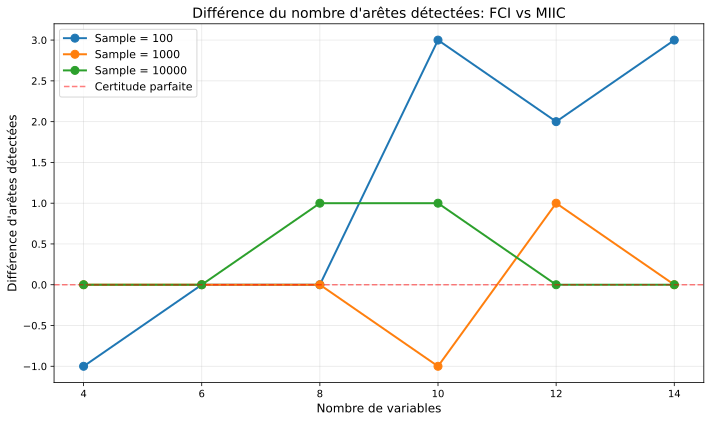


Résumé du nombre d'arêtes détectées:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | FCI:  1 arêtes | MIIC:  0 arêtes | Différence: -1
n= 6 variables | FCI:  1 arêtes | MIIC:  1 arêtes | Différence: +0
n= 8 variables | FCI:  2 arêtes | MIIC:  2 arêtes | Différence: +0
n=10 variables | FCI:  3 arêtes | MIIC:  6 arêtes | Différence: +3
n=12 variables | FCI:  4 arêtes | MIIC:  6 arêtes | Différence: +2
n=14 variables | FCI:  6 arêtes | MIIC:  9 arêtes | Différence: +3

Taille de l'échantillo s = 1000
n= 4 variables | FCI:  0 arêtes | MIIC:  0 arêtes | Différence: +0
n= 6 variables | FCI:  3 arêtes | MIIC:  3 arêtes | Différence: +0
n= 8 variables | FCI:  5 arêtes | MIIC:  5 arêtes | Différence: +0
n=10 variables | FCI:  7 arêtes | MIIC:  6 arêtes | Différence: -1
n=12 variables | FCI:  8 arêtes | MIIC:  9 arêtes | Différence: +1
n=14 variables | FCI:  6 arêtes | MIIC:  6 arêtes | Différence: +0

Taille de l'échantillo s = 1000

In [98]:
# Nombre d'arêtes trouvées par FCI vs MIIC
plt.figure(figsize=(10, 6))
for s in n_samples:
    diff = [(total_n_edges_miic[s][i] - total_n_edges_fci[s][i]) for i in range(len(n_vars_list))]
    plt.plot(n_vars_list, diff, marker='o', label=f'Sample = {s}', linewidth=2, markersize=8)
    # plt.plot(n_vars_list, total_n_edges_fci[s], marker='o', label=f'FCI ({s})', linewidth=2, markersize=8)
    # plt.plot(n_vars_list, n_edges_miic, marker='s', label=f'MIIC ({s})', linewidth=2, markersize=8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Certitude parfaite')

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Différence d\'arêtes détectées', fontsize=12)
plt.title('Différence du nombre d\'arêtes détectées: FCI vs MIIC', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)

plt.tight_layout()
plt.show()

# Affichage des statistiques détaillées
print("\nRésumé du nombre d'arêtes détectées:")
print("-" * 60)
for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        diff = total_n_edges_miic[s][i] - total_n_edges_fci[s][i]
        print(f"n={n:2d} variables | FCI: {total_n_edges_fci[s][i]:2d} arêtes | MIIC: {total_n_edges_miic[s][i]:2d} arêtes | Différence: {diff:+2d}")

### Taux de certitude FCI

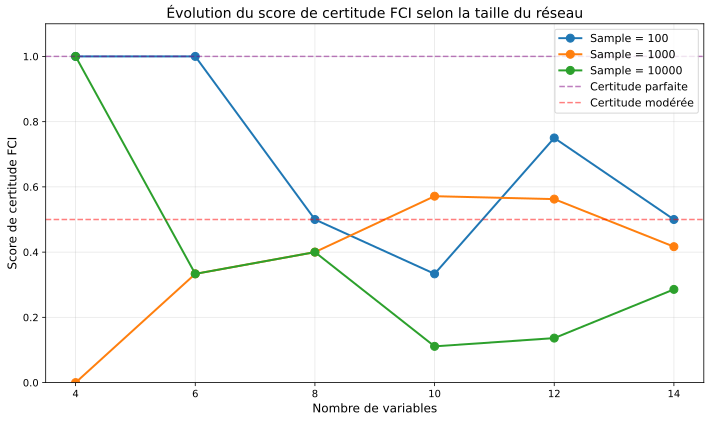


Résumé du score de certitude FCI:
------------------------------------------------------------

Taille de l'échantillo s = 100
n= 4 variables | Score de certitude: 1.000
n= 6 variables | Score de certitude: 0.333
n= 8 variables | Score de certitude: 0.400
n=10 variables | Score de certitude: 0.111
n=12 variables | Score de certitude: 0.136
n=14 variables | Score de certitude: 0.286

Taille de l'échantillo s = 1000
n= 4 variables | Score de certitude: 1.000
n= 6 variables | Score de certitude: 0.333
n= 8 variables | Score de certitude: 0.400
n=10 variables | Score de certitude: 0.111
n=12 variables | Score de certitude: 0.136
n=14 variables | Score de certitude: 0.286

Taille de l'échantillo s = 10000
n= 4 variables | Score de certitude: 1.000
n= 6 variables | Score de certitude: 0.333
n= 8 variables | Score de certitude: 0.400
n=10 variables | Score de certitude: 0.111
n=12 variables | Score de certitude: 0.136
n=14 variables | Score de certitude: 0.286


In [99]:
# Taux de certitude FCI
plt.figure(figsize=(10, 6))

for s in n_samples:
    plt.plot(n_vars_list, total_certainty_score[s], marker='o', linewidth=2, markersize=8, label=f'Sample = {s}')
plt.axhline(y=1, color='purple', linestyle='--', linewidth=1.5, alpha=0.5, label='Certitude parfaite')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Certitude modérée')

plt.xlabel('Nombre de variables', fontsize=12)
plt.ylabel('Score de certitude FCI', fontsize=12)
plt.title('Évolution du score de certitude FCI selon la taille du réseau', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(n_vars_list)
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Affichage des statistiques
print("\nRésumé du score de certitude FCI:")
print("-" * 60)
for s in n_samples:
    print("\nTaille de l'échantillo s =", s)
    for i, n in enumerate(n_vars_list):
        print(f"n={n:2d} variables | Score de certitude: {certainty_score[i]:.3f}")